<a href="https://colab.research.google.com/github/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/blob/main/Praktikum4/TugasRegularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
dataset_url = 'https://raw.githubusercontent.com/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/refs/heads/main/Praktikum4/Advertising.csv'

df = pd.read_csv(dataset_url)

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Data fitur:")
print(X.head())

print("\nData target:")
print(y.head())

Data fitur:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Data target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 160
Jumlah data testing: 40


In [5]:
def hitung_rmse(model, X_train_data, X_test_data, y_train, y_test):
    y_pred_train = model.predict(X_train_data)
    y_pred_test = model.predict(X_test_data)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    gap_rmse = abs(rmse_test - rmse_train)

    return rmse_train, rmse_test, gap_rmse

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

rmse_train_linear, rmse_test_linear, gap_linear = hitung_rmse(
    linear_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_linear = pd.Series(linear_model.coef_, index=X.columns)

print("Linear Regression")
print("RMSE Train:", rmse_train_linear)
print("RMSE Test :", rmse_test_linear)
print("Gap RMSE  :", gap_linear)
print("\nKoefisien Linear Regression:")
print(coef_linear)

Linear Regression
RMSE Train: 1.644727765644337
RMSE Test : 1.7815996615334506
Gap RMSE  : 0.13687189588911353

Koefisien Linear Regression:
TV           3.764196
Radio        2.792307
Newspaper    0.055976
dtype: float64


In [7]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

rmse_train_ridge, rmse_test_ridge, gap_ridge = hitung_rmse(
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_ridge = pd.Series(ridge_model.coef_, index=X.columns)

print("Ridge Regression alpha=1.0")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Gap RMSE  :", gap_ridge)
print("\nKoefisien Ridge:")
print(coef_ridge)

Ridge Regression alpha=1.0
RMSE Train: 1.6449869251443512
RMSE Test : 1.7872201577332218
Gap RMSE  : 0.14223323258887066

Koefisien Ridge:
TV           3.741693
Radio        2.773312
Newspaper    0.063380
dtype: float64


In [8]:
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

rmse_train_lasso, rmse_test_lasso, gap_lasso = hitung_rmse(
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

coef_lasso = pd.Series(lasso_model.coef_, index=X.columns)

print("Lasso Regression alpha=0.1")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Gap RMSE  :", gap_lasso)
print("\nKoefisien Lasso:")
print(coef_lasso)

Lasso Regression alpha=0.1
RMSE Train: 1.651292955720115
RMSE Test : 1.7913338117315942
Gap RMSE  : 0.1400408560114792

Koefisien Lasso:
TV           3.669206
Radio        2.719147
Newspaper    0.000000
dtype: float64


In [9]:
tabel_perbandingan = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge alpha=1.0",
        "Lasso alpha=0.1"
    ],
    "RMSE Train": [
        rmse_train_linear,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    "RMSE Test": [
        rmse_test_linear,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    "Gap RMSE": [
        gap_linear,
        gap_ridge,
        gap_lasso
    ]
})

tabel_perbandingan

,Model,RMSE Train,RMSE Test,Gap RMSE
0,Linear Regression,1.644728,1.781600,0.136872
1,Ridge alpha=1.0,1.644987,1.787220,0.142233
2,Lasso alpha=0.1,1.651293,1.791334,0.140041


In [10]:
tabel_koefisien = pd.DataFrame({
    "Fitur": X.columns,
    "Linear Regression": coef_linear.values,
    "Ridge alpha=1.0": coef_ridge.values,
    "Lasso alpha=0.1": coef_lasso.values
})

tabel_koefisien

,Fitur,Linear Regression,Ridge alpha=1.0,Lasso alpha=0.1
0,TV,3.764196,3.741693,3.669206
1,Radio,2.792307,2.773312,2.719147
2,Newspaper,0.055976,0.063380,0.000000


In [26]:
print("Gap RMSE Linear Regression:", gap_linear)
print("Gap RMSE Ridge:", gap_ridge)

if gap_ridge < gap_linear:
    print("Jawaban:")
    print("Ya, Ridge menurunkan gap RMSE antara train dan test.")
else:
    print("Jawaban:")
    print("Tidak, Ridge tidak menurunkan gap RMSE antara train dan test pada alpha=1.0.")

Gap RMSE Linear Regression: 0.13687189588911353
Gap RMSE Ridge: 0.14223323258887066
Jawaban:
Tidak, Ridge tidak menurunkan gap RMSE antara train dan test pada alpha=1.0.


In [12]:
print("Koefisien Lasso:")
print(coef_lasso)

fitur_nol = coef_lasso[coef_lasso == 0]

if len(fitur_nol) > 0:
    print("\nJawaban:")
    print("Ya, Lasso membuat beberapa koefisien menjadi nol.")
    print("Fitur dengan koefisien nol:")
    print(fitur_nol)
else:
    print("\nJawaban:")
    print("Tidak, Lasso tidak membuat koefisien menjadi nol pada alpha=0.1.")

Koefisien Lasso:
TV           3.669206
Radio        2.719147
Newspaper    0.000000
dtype: float64

Jawaban:
Ya, Lasso membuat beberapa koefisien menjadi nol.
Fitur dengan koefisien nol:
Newspaper    0.0
dtype: float64


In [13]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

hasil_alpha = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        ridge,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_alpha.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        lasso,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_alpha.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

hasil_alpha_df = pd.DataFrame(hasil_alpha)
hasil_alpha_df

,Model,Alpha,RMSE Train,RMSE Test,Gap RMSE
0,Ridge,0.001,1.644728,1.781605,0.136877
1,Lasso,0.001,1.644728,1.781587,0.136859
2,Ridge,0.010,1.644728,1.781654,0.136926
3,Lasso,0.010,1.644799,1.781551,0.136752
4,Ridge,0.100,1.644730,1.782143,0.137412
5,Lasso,0.100,1.651293,1.791334,0.140041
6,Ridge,1.000,1.644987,1.787220,0.142233
7,Lasso,1.000,2.146055,2.396806,0.250751
8,Ridge,10.000,1.667636,1.853716,0.186080
9,Lasso,10.000,5.092764,5.631496,0.538732


In [14]:
hasil_terbaik = hasil_alpha_df.loc[hasil_alpha_df["RMSE Test"].idxmin()]

print("Jawaban:")
print("RMSE test paling kecil diperoleh pada:")
print("Model     :", hasil_terbaik["Model"])
print("Alpha     :", hasil_terbaik["Alpha"])
print("RMSE Test :", hasil_terbaik["RMSE Test"])

Jawaban:
RMSE test paling kecil diperoleh pada:
Model     : Lasso
Alpha     : 0.01
RMSE Test : 1.781551217896262


In [15]:
hasil_alpha_df.sort_values(by=["Model", "Alpha"])

,Model,Alpha,RMSE Train,RMSE Test,Gap RMSE
1,Lasso,0.001,1.644728,1.781587,0.136859
3,Lasso,0.010,1.644799,1.781551,0.136752
5,Lasso,0.100,1.651293,1.791334,0.140041
7,Lasso,1.000,2.146055,2.396806,0.250751
9,Lasso,10.000,5.092764,5.631496,0.538732
11,Lasso,100.000,5.092764,5.631496,0.538732
0,Ridge,0.001,1.644728,1.781605,0.136877
2,Ridge,0.010,1.644728,1.781654,0.136926
4,Ridge,0.100,1.644730,1.782143,0.137412
6,Ridge,1.000,1.644987,1.787220,0.142233


In [16]:
alpha_besar = hasil_alpha_df[hasil_alpha_df["Alpha"] == max(alphas)]

print("Hasil pada alpha terbesar:")
print(alpha_besar)

print("\nJawaban:")
print("Jika RMSE Train dan RMSE Test meningkat pada alpha besar,")
print("maka alpha/lambda yang terlalu besar menyebabkan underfitting.")
print("Hal ini terjadi karena model terlalu dibatasi oleh regularization.")

Hasil pada alpha terbesar:
    Model  Alpha  RMSE Train  RMSE Test  Gap RMSE
10  Ridge  100.0    2.427323   2.786288  0.358965
11  Lasso  100.0    5.092764   5.631496  0.538732

Jawaban:
Jika RMSE Train dan RMSE Test meningkat pada alpha besar,
maka alpha/lambda yang terlalu besar menyebabkan underfitting.
Hal ini terjadi karena model terlalu dibatasi oleh regularization.


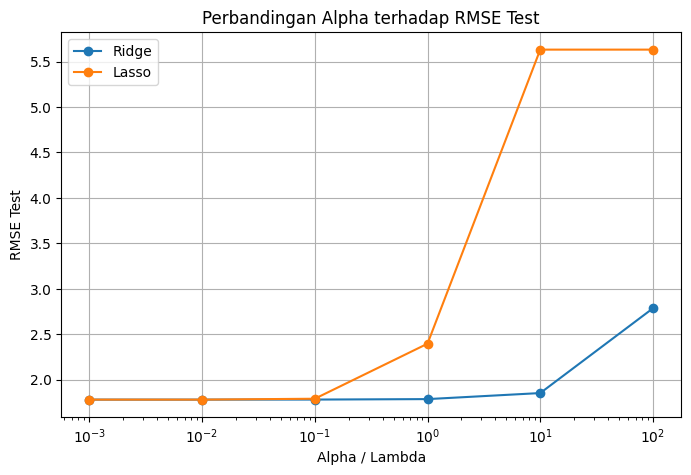

In [17]:
plt.figure(figsize=(8, 5))

for model in ["Ridge", "Lasso"]:
    data_model = hasil_alpha_df[hasil_alpha_df["Model"] == model]

    plt.plot(
        data_model["Alpha"],
        data_model["RMSE Test"],
        marker="o",
        label=model
    )

plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("RMSE Test")
plt.title("Perbandingan Alpha terhadap RMSE Test")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
extra_alphas = [0.0001, 0.005, 0.05, 0.5, 5, 50, 500]

hasil_extra = []

for alpha in extra_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        ridge,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_extra.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    rmse_train, rmse_test, gap = hitung_rmse(
        lasso,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    hasil_extra.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "RMSE Train": rmse_train,
        "RMSE Test": rmse_test,
        "Gap RMSE": gap
    })

hasil_extra_df = pd.DataFrame(hasil_extra)
hasil_extra_df

,Model,Alpha,RMSE Train,RMSE Test,Gap RMSE
0,Ridge,0.0001,1.644728,1.781600,0.136872
1,Lasso,0.0001,1.644728,1.781599,0.136871
2,Ridge,0.0050,1.644728,1.781627,0.136899
3,Lasso,0.0050,1.644746,1.781551,0.136806
4,Ridge,0.0500,1.644728,1.781871,0.137142
5,Lasso,0.0500,1.646506,1.783116,0.136610
6,Ridge,0.5000,1.644793,1.784357,0.139564
7,Lasso,0.5000,1.783881,1.978445,0.194564
8,Ridge,5.0000,1.650863,1.813578,0.162715
9,Lasso,5.0000,5.092764,5.631496,0.538732


In [19]:
ridge_coef_list = []

for alpha in extra_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    ridge_coef_list.append({
        "Alpha": alpha,
        "TV": ridge.coef_[0],
        "Radio": ridge.coef_[1],
        "Newspaper": ridge.coef_[2]
    })

ridge_coef_df = pd.DataFrame(ridge_coef_list)
ridge_coef_df

,Alpha,TV,Radio,Newspaper
0,0.0001,3.764194,2.792305,0.055976
1,0.0050,3.764083,2.792211,0.056013
2,0.0500,3.763065,2.791350,0.056351
3,0.5000,3.752911,2.782771,0.059705
4,5.0000,3.654290,2.700272,0.090947
5,50.0000,2.893292,2.103168,0.259073
6,500.0000,0.939108,0.698042,0.223666


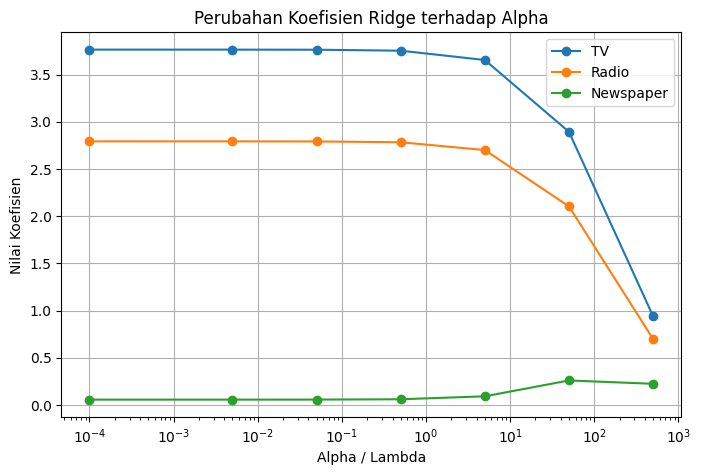

In [20]:
plt.figure(figsize=(8, 5))

for fitur in ["TV", "Radio", "Newspaper"]:
    plt.plot(
        ridge_coef_df["Alpha"],
        ridge_coef_df[fitur],
        marker="o",
        label=fitur
    )

plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("Nilai Koefisien")
plt.title("Perubahan Koefisien Ridge terhadap Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
lasso_coef_list = []

for alpha in extra_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)

    lasso_coef_list.append({
        "Alpha": alpha,
        "TV": lasso.coef_[0],
        "Radio": lasso.coef_[1],
        "Newspaper": lasso.coef_[2]
    })

lasso_coef_df = pd.DataFrame(lasso_coef_list)
lasso_coef_df

,Alpha,TV,Radio,Newspaper
0,0.0001,3.764098,2.792251,0.055899
1,0.0050,3.759442,2.788975,0.052359
2,0.0500,3.716679,2.758909,0.019843
3,0.5000,3.289653,2.339594,0.000000
4,5.0000,0.000000,0.000000,0.000000
5,50.0000,0.000000,0.000000,0.000000
6,500.0000,0.000000,0.000000,0.000000


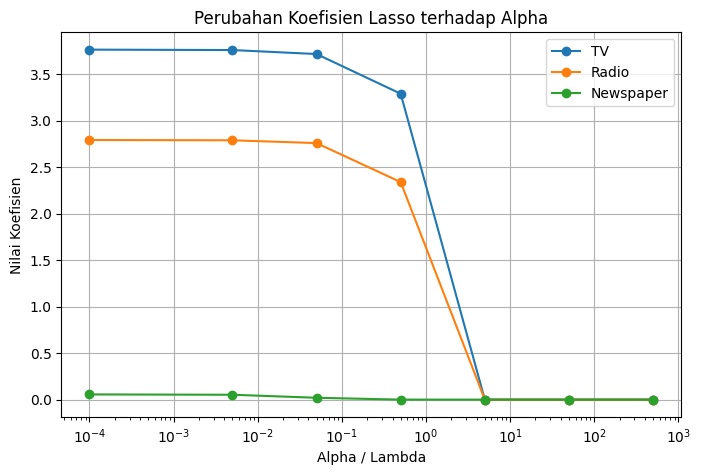

In [22]:
plt.figure(figsize=(8, 5))

for fitur in ["TV", "Radio", "Newspaper"]:
    plt.plot(
        lasso_coef_df["Alpha"],
        lasso_coef_df[fitur],
        marker="o",
        label=fitur
    )

plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("Nilai Koefisien")
plt.title("Perubahan Koefisien Lasso terhadap Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print("Koefisien Ridge pada berbagai alpha:")
display(ridge_coef_df)

print("Koefisien Lasso pada berbagai alpha:")
display(lasso_coef_df)

Koefisien Ridge pada berbagai alpha:


,Alpha,TV,Radio,Newspaper
0,0.0001,3.764194,2.792305,0.055976
1,0.0050,3.764083,2.792211,0.056013
2,0.0500,3.763065,2.791350,0.056351
3,0.5000,3.752911,2.782771,0.059705
4,5.0000,3.654290,2.700272,0.090947
5,50.0000,2.893292,2.103168,0.259073
6,500.0000,0.939108,0.698042,0.223666


Koefisien Lasso pada berbagai alpha:


,Alpha,TV,Radio,Newspaper
0,0.0001,3.764098,2.792251,0.055899
1,0.0050,3.759442,2.788975,0.052359
2,0.0500,3.716679,2.758909,0.019843
3,0.5000,3.289653,2.339594,0.000000
4,5.0000,0.000000,0.000000,0.000000
5,50.0000,0.000000,0.000000,0.000000
6,500.0000,0.000000,0.000000,0.000000


In [24]:
print("Analisis Ridge:")
print("Ridge mengecilkan koefisien secara bertahap ketika alpha semakin besar.")
print("Namun, Ridge biasanya tidak membuat koefisien menjadi nol.")

print("\nAnalisis Lasso:")
print("Lasso dapat mengecilkan koefisien hingga menjadi nol.")
print("Jika ada koefisien yang nol, berarti fitur tersebut tidak digunakan oleh model.")
print("Karena itu, Lasso dapat berfungsi sebagai feature selection.")

Analisis Ridge:
Ridge mengecilkan koefisien secara bertahap ketika alpha semakin besar.
Namun, Ridge biasanya tidak membuat koefisien menjadi nol.

Analisis Lasso:
Lasso dapat mengecilkan koefisien hingga menjadi nol.
Jika ada koefisien yang nol, berarti fitur tersebut tidak digunakan oleh model.
Karena itu, Lasso dapat berfungsi sebagai feature selection.
